Price Estimator — Roommate Project


## 1. Load Data

In [ ]:
import pandas as pd 
import numpy as np 
import warnings 
warnings.filterwarnings('ignore')

df = pd.read_csv('user_big2.csv')

 

In [3]:
df.shape

(5002, 12)

In [4]:
df.isna().sum()

user_id                 0
age                     0
gender                  0
occupation              0
smoking_status          0
pet_status              0
sleep_schedule          0
cleanliness             0
budget_min              0
budget_max              0
roommate_gender_pref    0
pref_smoking            0
dtype: int64

In [5]:
df.head()

,user_id,age,gender,occupation,smoking_status,pet_status,sleep_schedule,cleanliness,budget_min,budget_max,roommate_gender_pref,pref_smoking
0,1,24,MALE,Software Engineer,NON_SMOKER,NO_PETS,NIGHT_OWL,4,3000,5000,MALE,NOT_ALLOWED
1,2,22,FEMALE,Medical Student,NON_SMOKER,HAS_PETS,EARLY_BIRD,5,2000,4000,FEMALE,NOT_ALLOWED
2,3,20,MALE,Freelancer,SMOKER,NO_PETS,EARLY_BIRD,1,3646,6448,MALE,NOT_ALLOWED
3,4,26,FEMALE,Engineer,SMOKER,HAS_PETS,NIGHT_OWL,1,3237,5169,ANY,ALLOWED
4,5,28,MALE,Engineer,NON_SMOKER,NO_PETS,NIGHT_OWL,1,3802,6659,ANY,NOT_ALLOWED


In [6]:
df = df.drop(columns=['user_id'])

## 2. Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['gender', 'occupation', 'smoking_status', 'pet_status',
           'sleep_schedule', 'roommate_gender_pref', 'pref_smoking']
#call model 
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


print('After encoding:')
print(df.dtypes)
df.head()
 

After encoding:
age                     int64
gender                  int64
occupation              int64
smoking_status          int64
pet_status              int64
sleep_schedule          int64
cleanliness             int64
budget_min              int64
budget_max              int64
roommate_gender_pref    int64
pref_smoking            int64
dtype: object


,age,gender,occupation,smoking_status,pet_status,sleep_schedule,cleanliness,budget_min,budget_max,roommate_gender_pref,pref_smoking
0,24,1,5,0,1,1,4,3000,5000,2,1
1,22,0,4,0,0,0,5,2000,4000,1,1
2,20,1,3,1,1,0,1,3646,6448,2,1
3,26,0,2,1,0,1,1,3237,5169,0,0
4,28,1,2,0,1,1,1,3802,6659,0,1


## 3. Visualizations

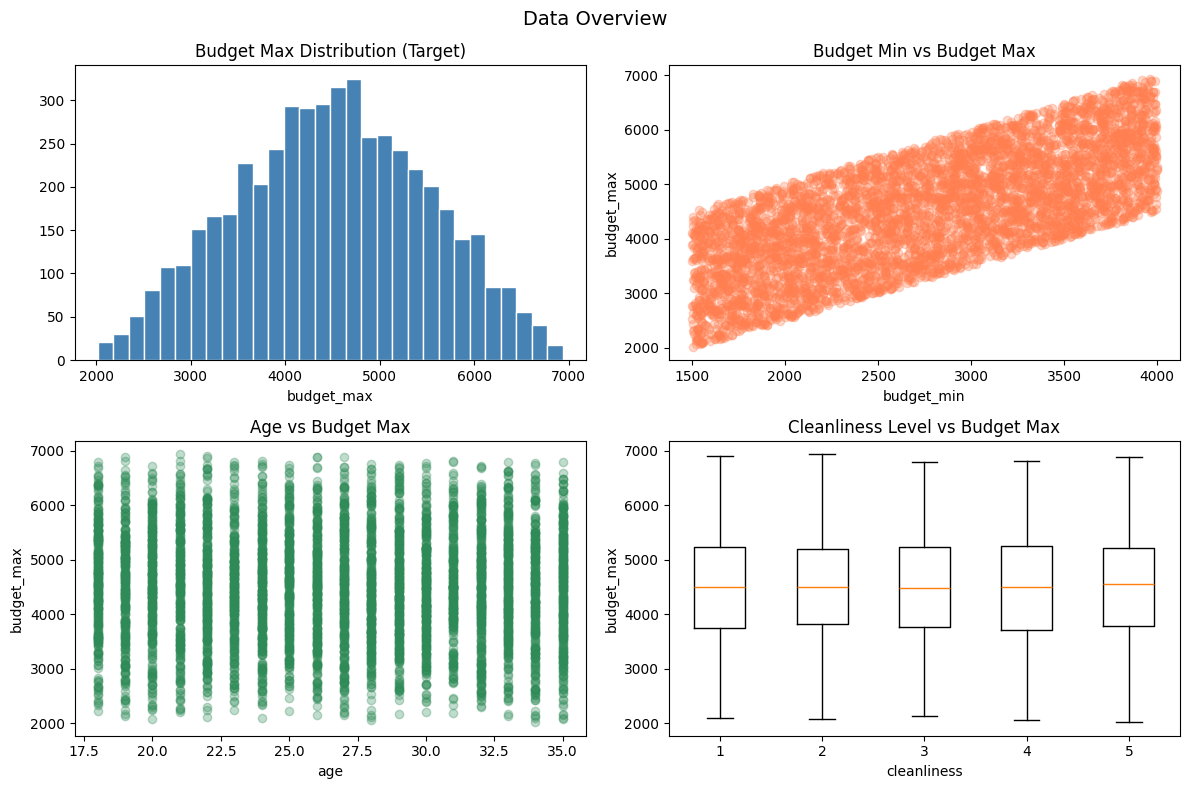

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Data Overview', fontsize=14)

# 1. Target distribution
axes[0, 0].hist(df['budget_max'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Budget Max Distribution (Target)')
axes[0, 0].set_xlabel('budget_max')

# 2. Budget min vs max scatter
axes[0, 1].scatter(df['budget_min'], df['budget_max'], alpha=0.3, color='coral')
axes[0, 1].set_title('Budget Min vs Budget Max')
axes[0, 1].set_xlabel('budget_min')
axes[0, 1].set_ylabel('budget_max')

# 3. Age vs budget_max
axes[1, 0].scatter(df['age'], df['budget_max'], alpha=0.3, color='seagreen')
axes[1, 0].set_title('Age vs Budget Max')
axes[1, 0].set_xlabel('age')
axes[1, 0].set_ylabel('budget_max')

# 4. Cleanliness vs budget_max
axes[1, 1].boxplot(
    [df[df['cleanliness'] == c]['budget_max'].values for c in sorted(df['cleanliness'].unique())],
    labels=sorted(df['cleanliness'].unique())
)
axes[1, 1].set_title('Cleanliness Level vs Budget Max')
axes[1, 1].set_xlabel('cleanliness')
axes[1, 1].set_ylabel('budget_max')

plt.tight_layout()
plt.show()

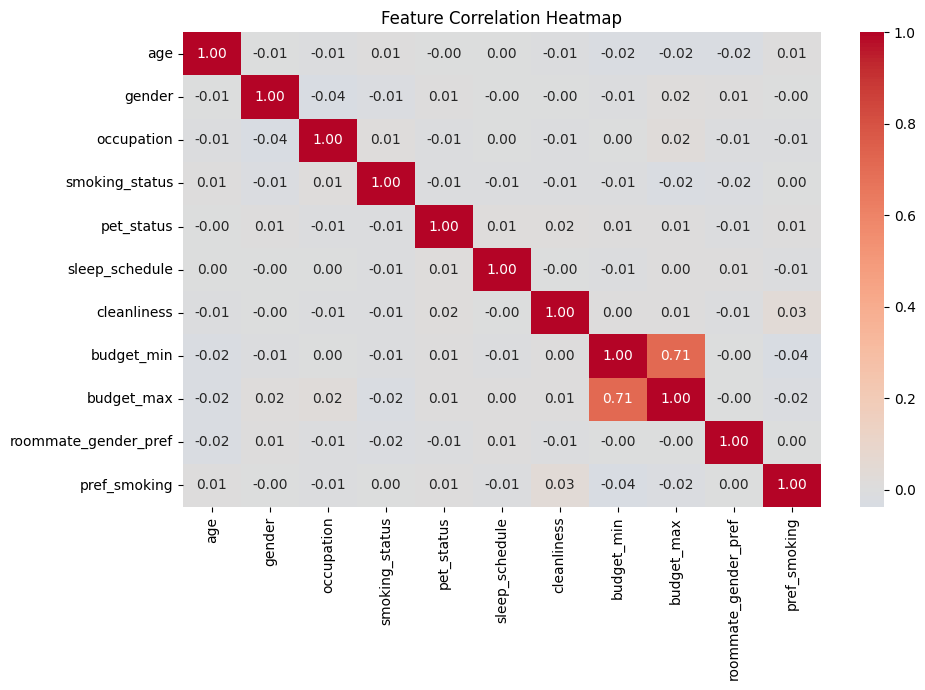

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True , fmt='.2f' , cmap='coolwarm',center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()
 

## 4. Select Target & Split X, y

In [ ]:
from sklearn.model_selection import train_test_split
TARGET = 'budget_max'


X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f'Train size : {X_train.shape[0]} rows')
print(f'Test size  : {X_test.shape[0]} rows')
print(f'Features   : {X.columns.tolist()}')
 

Train size : 4001 rows
Test size  : 1001 rows
Features   : ['age', 'gender', 'occupation', 'smoking_status', 'pet_status', 'sleep_schedule', 'cleanliness', 'budget_min', 'roommate_gender_pref', 'pref_smoking']


## 5. Train the Model

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f'MAE : {mae:.2f}  (average error in EGP)')
print(f'R²  : {r2:.4f}  (1.0 = perfect)')

MAE : 622.45  (average error in EGP)
R²  : 0.4746  (1.0 = perfect)


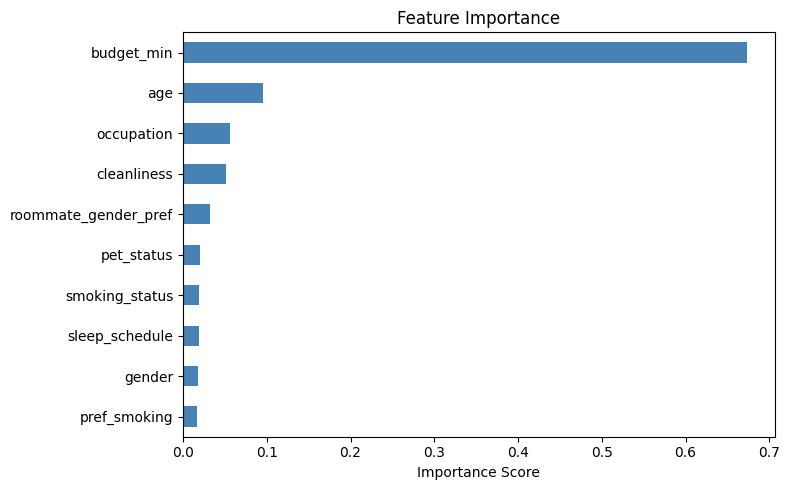

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

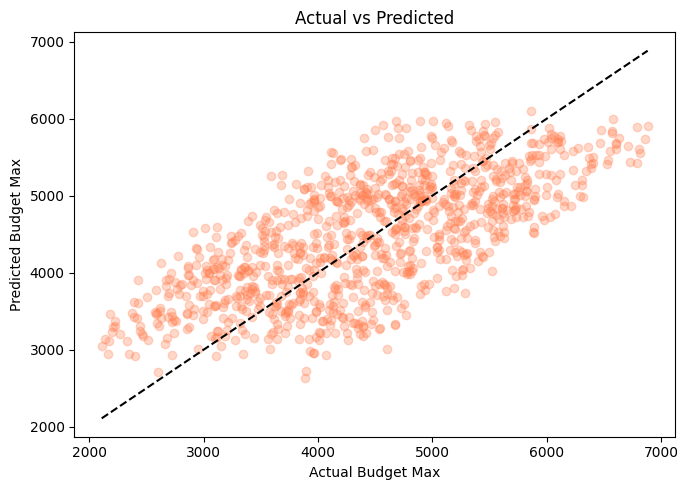

In [8]:
# Actual vs Predicted plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='coral')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1.5)
plt.xlabel('Actual Budget Max')
plt.ylabel('Predicted Budget Max')
plt.title('Actual vs Predicted')
plt.tight_layout()
plt.show()

## 6. Save the Model

In [9]:
import joblib

joblib.dump(model, 'price_estimator_model.pkl')
print('Model saved as price_estimator_model.pkl')

Model saved as price_estimator_model.pkl
